Embeddings : (2409, 64)
Train/Val/Test split: 1445 / 481 / 483
Fit set    : (1926, 64)
Test set   : (483, 64)
Observed event rate (fit) : 0.518
Observed event rate (test): 0.516
Median follow-up (fit)    : 119.37
Median follow-up (test)   : 131.29


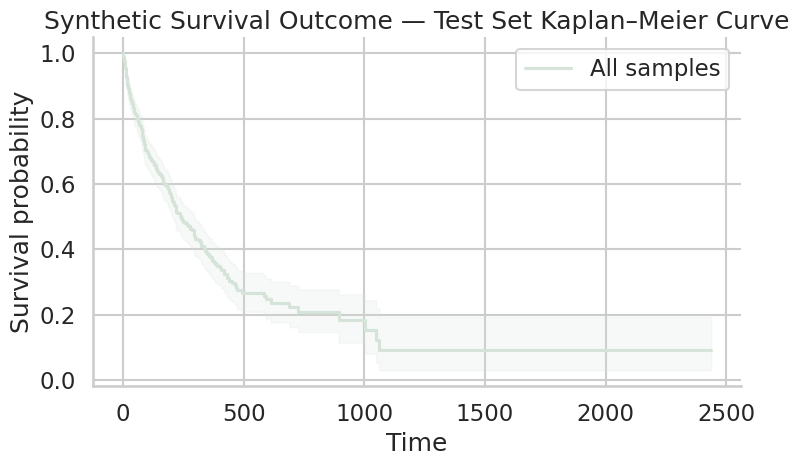

Cox PH                C-index=0.6774  t=0.21s
Penalized Cox PH      C-index=0.6787  t=2.15s
Weibull AFT           C-index=0.6770  t=0.36s


,Concordance Index,Time (s)
Model,,
Penalized Cox PH,0.6787,2.1480
Cox PH,0.6774,0.2060
Weibull AFT,0.6770,0.3600


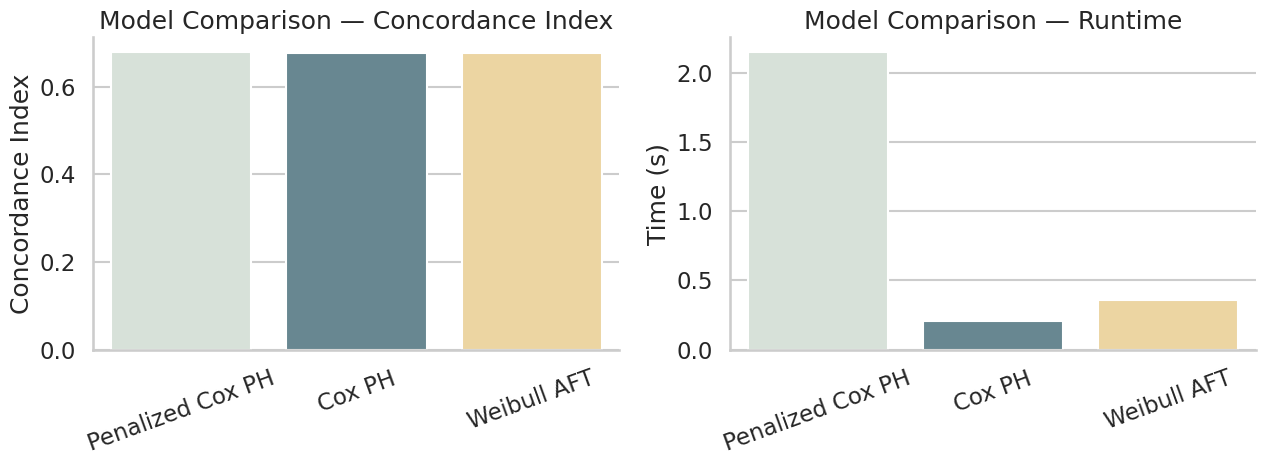

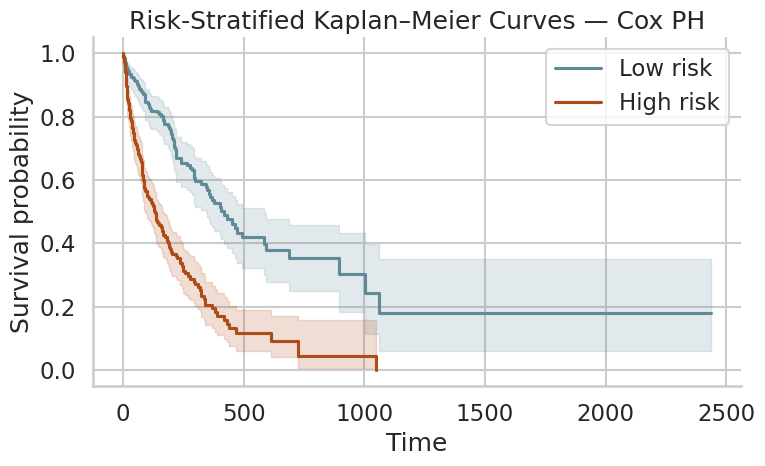

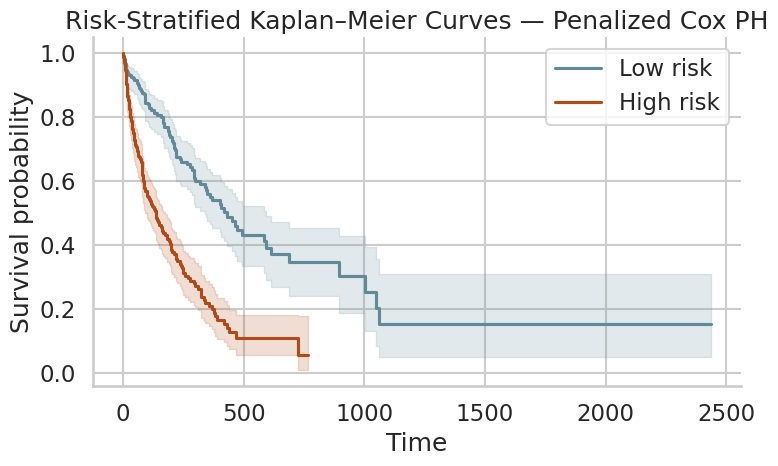

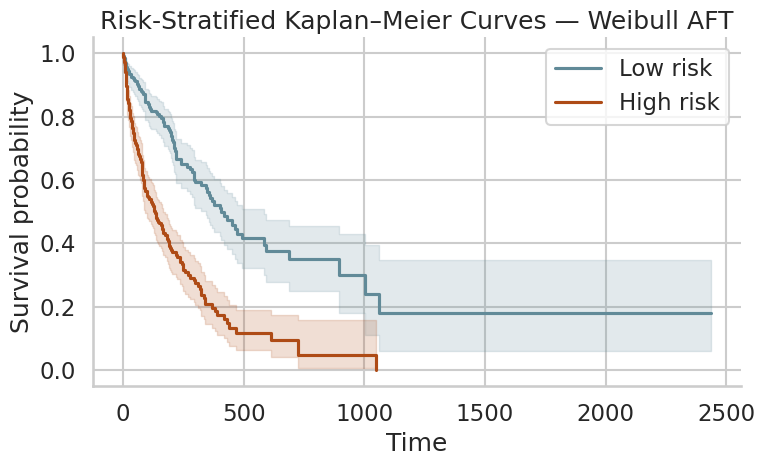

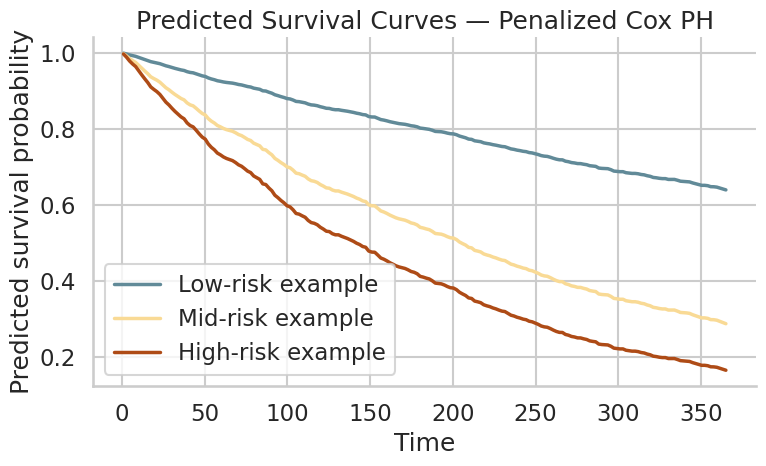

In [1]:
# ============================================================
# Survival Analysis on GNN Embeddings — YEAST Dataset
# Seaborn + palettable (wesanderson.Darjeeling2_5)
# ============================================================

import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

from lifelines import CoxPHFitter, WeibullAFTFitter
from palettable.wesanderson import Darjeeling2_5

import sys
sys.path.insert(0 , './../MAIN/')
from applications import  plot_model_comparison, plot_risk_stratified_km, plot_overall_km, eval_survival_model

# ── Config ────────────────────────────────────────────────────────────────────
PKL_PATH      = "/work/gr-fe/bryan/data/YEAST/03_final/yeast_gnn_embeddings.pkl"
RANDOM_STATE  = 42
TIME_HORIZON  = 365.0
N_RISK_FEATS  = 8
CENSOR_RATE   = 0.35
TEST_TIME_GRID = np.linspace(1, TIME_HORIZON, 200)

# ── Plot style ────────────────────────────────────────────────────────────────
PALETTE = Darjeeling2_5.mpl_colors
sns.set_theme(style="whitegrid", context="talk", palette=PALETTE)

# Convenient named colors
COL_1, COL_2, COL_3, COL_4, COL_5 = PALETTE

# ── 1. Load embeddings ────────────────────────────────────────────────────────
with open(PKL_PATH, "rb") as f:
    blob = pickle.load(f)

H         = blob["embeddings"]
train_idx = blob["train_idx"]
val_idx   = blob["val_idx"]
test_idx  = blob["test_idx"]

print(f"Embeddings : {H.shape}")
print(f"Train/Val/Test split: {len(train_idx)} / {len(val_idx)} / {len(test_idx)}")

# ── 2. Build train / test sets ───────────────────────────────────────────────
fit_idx = np.concatenate([train_idx, val_idx])
X_train = H[fit_idx]
X_test  = H[test_idx]

print(f"Fit set    : {X_train.shape}")
print(f"Test set   : {X_test.shape}")

# ── 3. Create synthetic survival target ──────────────────────────────────────
def make_dummy_survival_targets(
    X,
    random_state=42,
    n_risk_feats=8,
    censor_rate=0.35,
    time_scale=365.0,
):
    rng = np.random.default_rng(random_state)

    X = np.asarray(X, dtype=np.float64)
    N, D = X.shape

    p = min(n_risk_feats, D)
    Z = X[:, :p].copy()
    Z = (Z - Z.mean(axis=0)) / (Z.std(axis=0) + 1e-8)

    beta = rng.normal(loc=0.0, scale=0.6, size=p)
    mask = rng.uniform(size=p) > 0.35
    beta *= mask

    linpred = Z @ beta
    if p >= 3:
        linpred += 0.25 * Z[:, 0] * Z[:, 1] - 0.15 * (Z[:, 2] ** 2)

    linpred = (linpred - linpred.mean()) / (linpred.std() + 1e-8)
    hazard_multiplier = np.exp(0.8 * linpred)

    base_hazard = 1.0 / time_scale
    event_times = rng.exponential(scale=1.0 / (base_hazard * hazard_multiplier))

    censor_scale = np.quantile(event_times, 1.0 - censor_rate)
    censor_times = rng.exponential(scale=max(censor_scale, 1e-3), size=N)

    durations = np.minimum(event_times, censor_times)
    events = (event_times <= censor_times).astype(int)
    durations = np.clip(durations, 1e-3, None)

    return durations, events, linpred

dur_all, evt_all, risk_all = make_dummy_survival_targets(
    H,
    random_state=RANDOM_STATE,
    n_risk_feats=N_RISK_FEATS,
    censor_rate=CENSOR_RATE,
    time_scale=TIME_HORIZON,
)

dur_train, evt_train = dur_all[fit_idx], evt_all[fit_idx]
dur_test,  evt_test  = dur_all[test_idx], evt_all[test_idx]

print(f"Observed event rate (fit) : {evt_train.mean():.3f}")
print(f"Observed event rate (test): {evt_test.mean():.3f}")
print(f"Median follow-up (fit)    : {np.median(dur_train):.2f}")
print(f"Median follow-up (test)   : {np.median(dur_test):.2f}")

# ── 4. Build survival DataFrames ─────────────────────────────────────────────
feature_cols = [f"emb_{i}" for i in range(H.shape[1])]

df_train = pd.DataFrame(X_train, columns=feature_cols)
df_train["time"] = dur_train
df_train["event"] = evt_train

df_test = pd.DataFrame(X_test, columns=feature_cols)
df_test["time"] = dur_test
df_test["event"] = evt_test

# ── 5. Plot overall KM baseline ──────────────────────────────────────────────
plot_overall_km(
    durations=dur_test,
    events=evt_test,
    title="Synthetic Survival Outcome — Test Set Kaplan–Meier Curve",
    COL=COL_1
)

# ── 6. Fit survival models ───────────────────────────────────────────────────
survival_models = {
    "Cox PH": CoxPHFitter(),
    "Penalized Cox PH": CoxPHFitter(penalizer=0.1, l1_ratio=0.5),
    "Weibull AFT": WeibullAFTFitter(),
}

results = []

for name, mdl in survival_models.items():
    if "Weibull" in name:
        out = eval_survival_model(mdl, df_train, df_test, name, pred_type="median")
    else:
        out = eval_survival_model(mdl, df_train, df_test, name, pred_type="partial_hazard")

    results.append(out)
    print(
        f"{name:<20s}  "
        f"C-index={out['Concordance Index']:.4f}  "
        f"t={out['Time (s)']:.2f}s"
    )

# ── 7. Compare models in table + seaborn plot ────────────────────────────────
df_results = (
    pd.DataFrame([
        {
            "Model": r["Model"],
            "Concordance Index": r["Concordance Index"],
            "Time (s)": r["Time (s)"],
        }
        for r in results
    ])
    .sort_values("Concordance Index", ascending=False)
    .set_index("Model")
)

display(
    df_results.style
    .background_gradient(subset=["Concordance Index"], cmap="Greens")
    .background_gradient(subset=["Time (s)"], cmap="Blues_r")
    .format(precision=4)
    .set_caption("Survival Models on GNN Embeddings")
)

plot_model_comparison(df_results, palette=PALETTE)

# ── 8. Plot risk-stratified KM curves ────────────────────────────────────────
for r in results:
    plot_risk_stratified_km(
        durations=dur_test,
        events=evt_test,
        risk_scores=r["risk_scores"],
        title=f"Risk-Stratified Kaplan–Meier Curves — {r['Model']}",
        COL_1=COL_2,
        COL_2=COL_4
    )

# ── 9. Predicted survival curves for representative cases ────────────────────
best_result = max(results, key=lambda z: z["Concordance Index"])
best_model = best_result["model"]
best_name = best_result["Model"]
best_scores = np.asarray(best_result["risk_scores"]).reshape(-1)

order = np.argsort(best_scores)
idx_low  = order[len(order) // 10]
idx_mid  = order[len(order) // 2]
idx_high = order[(9 * len(order)) // 10]

example_idx = [idx_low, idx_mid, idx_high]
example_lbl = ["Low-risk example", "Mid-risk example", "High-risk example"]
example_cols = [COL_2, COL_3, COL_4]

fig, ax = plt.subplots(figsize=(8, 5))

for idx, lbl, col in zip(example_idx, example_lbl, example_cols):
    row = df_test.iloc[[idx]]
    sf = best_model.predict_survival_function(row, times=TEST_TIME_GRID)
    ax.plot(TEST_TIME_GRID, sf.values[:, 0], label=lbl, color=col, linewidth=2.5)

ax.set_title(f"Predicted Survival Curves — {best_name}")
ax.set_xlabel("Time")
ax.set_ylabel("Predicted survival probability")
ax.legend(frameon=True)
sns.despine()
plt.tight_layout()
plt.show()